In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import os,re

print("tensorflow version"+tf.__version__)

tensorflow version2.19.0


检查GPU使用情况和执行分布训练策略

In [3]:
gpus=tf.config.list_physical_devices("GPU")
print("GPUs:",gpus)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
if len(gpus)>1:
    strategy=tf.distribute.MirroredStrategy()
else:
    strategy=tf.distribute.get_strategy()

print("Replicas:",strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Replicas: 2


I0000 00:00:1782921874.003790      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782921874.009806      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


数据导入

In [5]:
AUTO=tf.data.experimental.AUTOTUNE
IMAGE_SIZE=[192,192]
BATCH_SIZE=32*strategy.num_replicas_in_sync
NUM_CLASSES=104

DATA_PATH="/kaggle/input/competitions/tpu-getting-started/tfrecords-jpeg-192x192"
TRAINING_FILENAMES = tf.io.gfile.glob(DATA_PATH+"/train/*.tfrec")
VALIDATION_FILENAMES=tf.io.gfile.glob(DATA_PATH+"/train/*.tfrec")
TEST_FILENAMES=tf.io.gfile.glob(DATA_PATH+"/train/*.tfrec")

print("Train files:",len(TRAINING_FILENAMES))
print("Val files:",len(VALIDATION_FILENAMES))
print("Test files:",len(TEST_FILENAMES))

def count_data_items(filenames):
    nums = [
        int(re.compile(r"-([0-9]*)\.").search(filename).group(1))
        for filename in filenames
    ]
    return np.sum(nums)

NUM_TRAINING_IMAGES=count_data_items(TRAINING_FILENAMES)
NUM_VAL_IMAGES=count_data_items(VALIDATION_FILENAMES)
NUM_TEST_IMAGES=count_data_items(TEST_FILENAMES)

print("Train files number:",NUM_TRAINING_IMAGES)
print("Val files number:",NUM_VAL_IMAGES)
print("Test files number:",NUM_TEST_IMAGES)

Train files: 16
Val files: 16
Test files: 16
Train files number: 12753
Val files number: 12753
Test files number: 12753


数据处理

首先约定labeled数据的记录格式，然后根据格式将example解码，解码后的内容 按照format重新替换example，这样example中就存在的是”image“对应的字节流和class对应的字节流 image

In [14]:
#解码图像变成192*192*3的多维向量，先制定通道数浮点转换方便后续归一化，将解码后的图像重塑为指定的尺寸
def decode_image(image_data):
    image=tf.image.decode_jpeg(image_data,channels=3)
    image=tf.cast(image,tf.float32)
    image=tf.reshape(image,[*IMAGE_SIZE,3])
    return image

#处理有标记数据
def read_labeled_tfrecord(example):
    LABELED_TFREC_FORMATE={
        "image":tf.io.FixedLenFeature([],tf.string),
        "class":tf.io.FixedLenFeature([],tf.int64),
    }
    example=tf.io.parse_single_example(example,LABELED_TFREC_FORMATE)
    image=decode_image(example["image"])
    label=tf.cast(example["class"],tf.int32)
    return image,label

def read_unlabeled_tfrecord(example):
    UNLABELED_TFREC_FORMAT={
        "image":tf.io.FixedLenFeature([],tf.string),
        "id":tf.io.FixedLenFeature([],tf.string),
    }
    example=tf.io.parse_single_example(example,UNLABELED_TFREC_FORMAT)
    image=decode_image(example["image"])
    image_id=example["id"]
    return image, image_id

强化数据

In [15]:
def data_augment(image,label):
    image=tf.image.random_flip_left_right(image)
    image=tf.image.random_contrast(image,0.9,1.1)
    image=tf.image.random_brightness(image,0.88)
    return image,label

In [16]:
def preprocess_labeled(image,label):
    image=tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image,label

def preprocess_unlabeled(image,image_id):
    image=tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image,image_id

加载数据

In [17]:
def load_dataset(filenames,labeled=True,ordered=False):
    options=tf.data.Options()
    if not ordered:
        options.experimental_deterministic=False
        
    dataset=tf.data.TFRecordDataset(filenames,num_parallel_reads=AUTO)
    dataset=dataset.with_options(options)

    if labeled:
        dataset=dataset.map(read_labeled_tfrecord,num_parallel_calls=AUTO)
    else:
        dataset=dataset.map(read_unlabeled_tfrecord,num_parallel_calls=AUTO)
    return dataset


完整数据流水线：
1.加载数据，给数据带标签
2.数据增强
3.预处理
4.repeat
5.shuffle打乱顺序
6.batch
7.prefetch

In [18]:
def get_training_dataset():
    dataset=load_dataset(TRAINING_FILENAMES,labeled=True)
    dataset=dataset.map(data_augment,num_parallel_calls=AUTO)
    dataset=dataset.map(preprocess_labeled,num_parallel_calls=AUTO)
    dataset=dataset.repeat()
    dataset=dataset.shuffle(2048)
    dataset=dataset.batch(BATCH_SIZE)
    dataset=dataset.prefetch(AUTO)
    return dataset

def get_validation_dataset():
    dataset=load_dataset(VALIDATION_FILENAMES,labeled=True,ordered=True)
    dataset=dataset.map(preprocess_unlabeled,num_parallel_calls=AUTO)
    dataset=dataset.batch(BATCH_SIZE)
    dataset=dataset.prefetch(AUTO)
    return dataset

def get_test_dataset():
    dataset=load_dataset(TEST_FILENAMES,labeled=False,ordered=True)
    dataset=dataset.map(preprocess_unlabeled,num_parallel_calls=AUTO)
    dataset=dataset.batch(BATCH_SIZE)
    dataset=dataset.prefetch(AUTO)
    return dataset


构建模型架构，配置训练参数

In [19]:
with strategy.scope():
    #Transfer Learning
    try:
        base_model=tf.keras.applications.MobileNetV2(
            input_shape=[*IMAGE_SIZE,3],
            include_top=False,
            weights="imagenet"
        )
        print('成功加载预训练权重')
    except Exception as e:
        print("预训练权重加载失败，权重参数随机化")
        print(e)
        base_model=tf.keras.application.MobileNetV2(
            input_shape[*IMAGE_SIZE,3],
            include_top=False,
            weights=None
        )

    base_model.trainable=False #冻结参数
    #定义后面几层的模型
    model=tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(NUM_CLASSES,activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["sparse_categorical_accuracy"],
    )

model.summary()

成功加载预训练权重


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_192            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 104)            │       133,224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,391,208 (9.12 MB)

 Trainable params: 133,224 (520.41 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

模型训练加测试推理

In [ ]:
EPOCHS=10
STEPS_PER_EPOCH=NUM_TRAINING_IMAGES//BATCH_SIZE

history=model.fit(
    get_training_dataset(),
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=get_validation_dataset()
)

test_dataset=get_test_dataset()
test_images=test_dataset.map(lambda image,image_id:image)
test_ids_dataset=test_dataset.map(lambda image,image_id:image_id).unbatch()

predictions=model.predict(test_images)
predicted_labels=np.argmax(predictions,axis=1)

test_ids=next(iter(test_ids_dataset.batch(NUM_TEST_IMAGES))).numpy().astype("U")

submission=pd.DataFrame({
    "id":test_ids,
    "label":predicted_labels
})

submission.to_csv("/kaggle/working/submission.csv",index=False)

print("submission.csv 已生成")
submission.head()

Epoch 1/10
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.3242 - sparse_categorical_accuracy: 0.9124

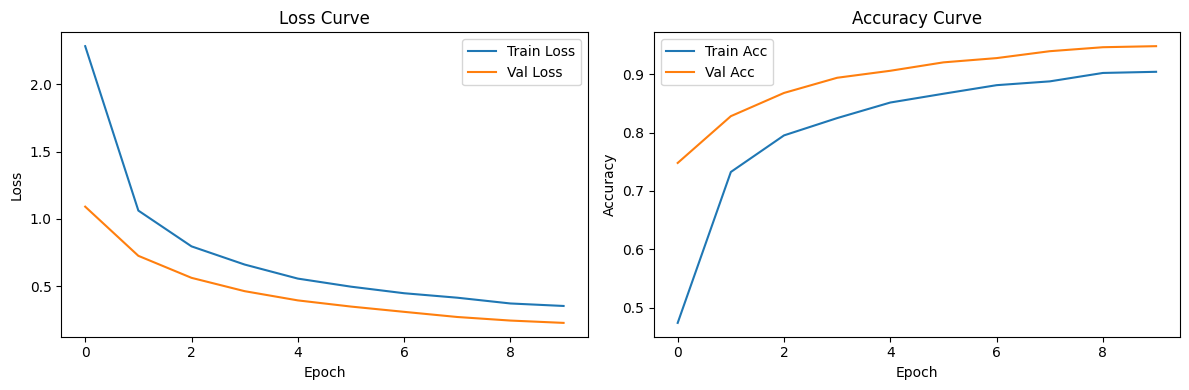

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['sparse_categorical_accuracy'], label='Train Acc')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()